<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_20940\268096089.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax3.plot(x, y, label=r"$\mu$ = " + str(i) + ", 1$\sigma$ = 1")


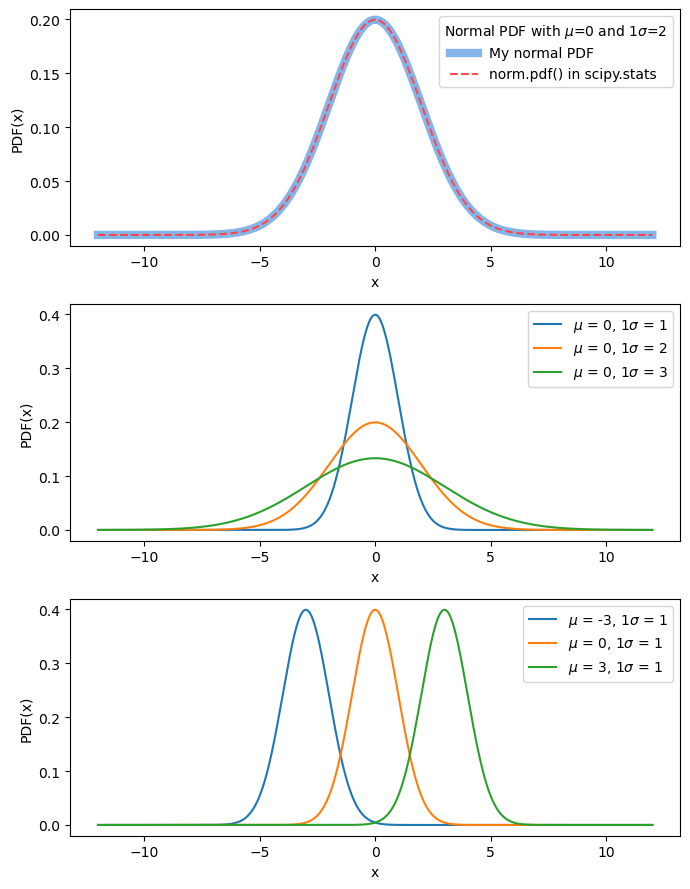

In [ ]:
# Mengimpor fungsi distribusi normal dari SciPy
from scipy.stats import norm
# Mengimpor library untuk membuat grafik
import matplotlib.pyplot as plt
# Mengimpor NumPy untuk komputasi numerik
import numpy as np 


# Mendefinisikan fungsi probability density function (PDF) distribusi normal secara manual
def normal_pdf(x, mean, std):
    # Rumus PDF distribusi normal: 1/(sqrt(2πσ²)) * exp(-0.5 * ((x-μ)² / σ²))
    return 1/(np.sqrt(2*np.pi*std**2))*np.exp(-0.5*((x - mean)**2)/(std**2))

# Membuat array nilai x dari -12 sampai 12 dengan jarak 0.001
x = np.arange(-12, 12, .001)

# Menghitung PDF normal menggunakan fungsi buatan sendiri (mean=0, std=2)
pdf1 = normal_pdf(x, mean=0, std=2)

# Menghitung PDF normal menggunakan fungsi bawaan scipy.stats
pdf2 = norm.pdf(x, loc=0, scale=2)

# Membuat figure untuk plot dengan ukuran 7x9 inch
fig = plt.figure(figsize=(7,9))
# Membuat subplot pertama (posisi 3 baris, 1 kolom, plot ke-1)
ax1 = fig.add_subplot(3, 1, 1)
# Plot PDF hasil buatan sendiri
ax1.plot(x,pdf1, color="#00244b", linestyle="-", linewidth=6, label="My normal PDF")
# Plot PDF dari scipy untuk dibandingkan
ax1.plot(x,pdf2, color="#251c1c", linestyle="--", label="norm.pdf() in scipy.stats ")
# Label sumbu X
ax1.set_xlabel("x")
# Label sumbu Y
ax1.set_ylabel("modul")
# Menampilkan legenda dengan judul (ditulis dalam format LaTeX)
ax1.legend(title = r"Normal PDF with $\mu$=0 and 1$\sigma$=2")

# Subplot kedua
ax2 = fig.add_subplot(3, 1, 2)
# Loop untuk beberapa nilai standar deviasi (σ)
for i in [1, 2, 3]:
     # Menghitung PDF untuk tiap nilai sigma
     y = normal_pdf(x,0,i)
     # Plot setiap kurva
     ax2.plot(x, y, label=r"$\mu$ = 0, 1$\sigma$ = " + str(i))
# Label sumbu
ax2.set_xlabel("x")
ax2.set_ylabel("PDF(x)")
# Menampilkan legenda
ax2.legend()

# Subplot ketiga
ax3 = fig.add_subplot(3, 1, 3)
# Loop untuk beberapa nilai mean (μ)
for i in [-3, 0, 3]:
     # Menghitung PDF dengan mean berbeda tapi sigma tetap 1
     y = normal_pdf(x, i, 1)
     # Plot hasilnya
     ax3.plot(x, y, label=r"$\mu$ = " + str(i) + ", 1$\sigma$ = 1")
# Label sumbu
ax3.set_xlabel("x")
ax3.set_ylabel("PDF(x)")
# Menampilkan legenda
ax3.legend()
# Mengatur layout agar tidak saling tumpang tindih
fig.tight_layout()

In [ ]:
# Mengimpor fungsi distribusi normal dari SciPy
from scipy.stats import norm
# Mengimpor NumPy untuk operasi numerik
import numpy as np
# Mengimpor fungsi matematika khusus (seperti error function)
from scipy import special
# Mengimpor fungsi integrasi numerik
from scipy import integrate

# Fungsi untuk menghitung integral distribusi normal secara analitik menggunakan error function (erf)
def integrate_normal(x1, x2, mu, sigma):
    # Rumus CDF normal menggunakan erf:
    # P(x1 ≤ X ≤ x2) = 0.5 * [erf((x2-μ)/(σ√2)) - erf((x1-μ)/(σ√2))]
    sup = 0.5*((special.erf((x2-mu)/(sigma*np.sqrt(2))))-(special.erf((x1-mu)/(sigma*np.sqrt(2)))))
    return sup
# Mean distribusi normal
my_mu = 0
# Standar deviasi distribusi normal
my_sigma = 1

# Batas bawah integral
my_x1 = 0
# Batas atas integral (1 standar deviasi dari mean)
my_x2 =  my_sigma

# Nilai teoritis (expected value area di bawah kurva normal antara 0 dan 1σ)
my_sup = integrate_normal(x1= my_x1, x2= my_x2, mu = my_mu, sigma = my_sigma)
# Membuat array x untuk pendekatan numerik
x = np.arange(my_x1, my_x2, 0.0001)
# Menghitung PDF normal menggunakan scipy
y =  norm.pdf(x, loc=my_mu, scale= my_sigma) # normal_pdf(x, mean = my_mu, std = my_sigma)

# Menghitung integral numerik menggunakan metode trapezoid
sup_trapz = integrate.trapezoid(y,x)
# Menghitung integral numerik menggunakan metode Simpson
sup_simps = integrate.simpson(y,x)

# Menampilkan hasil metode analitik (erf)
print("Solution Using erf: {:.9f}".format(my_sup))
# Menampilkan hasil metode trapezoid
print("Using the trapezoidal rule, trapz: {:.10f}".format(sup_trapz))
# Menampilkan hasil metode Simpson
print("Using the composite Simpson rule, simps: {:.10f}".format(sup_simps))

Solution Using erf: 0.341344746
Using the trapezoidal rule, trapz: 0.3413205476
Using the composite Simpson rule, simps: 0.3413205478


'\nOutput:\nSolution Using erf: 0.341344746\nUsing the trapezoidal rule, trapz: 0.3413205476\nUsing the composite Simpson rule, simps: 0.3413205478\n'

Sample mean equal to 0.0067
Sample standard deviation equal to 1.0075


'\nOutput: (your results will be sighly different because of the pseudo-random nature of the distribution)\nSample mean equal to -0.0014\nSample standard deviation equal to 1.0014\n'

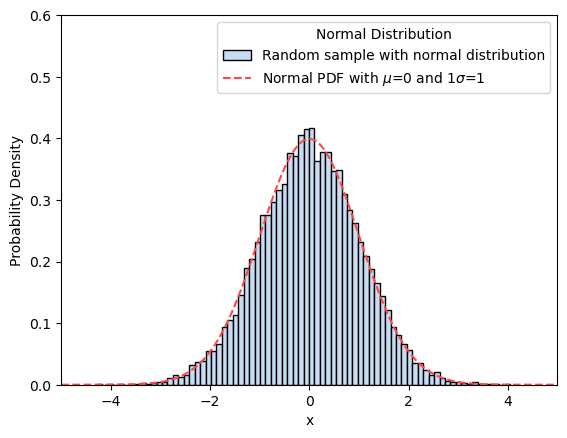

In [ ]:
# Mengimpor NumPy untuk operasi numerik dan data acak
import numpy as np
# Mengimpor distribusi normal dari SciPy
from scipy.stats import norm
# Mengimpor Matplotlib untuk membuat grafik
import matplotlib.pyplot as plt

# Menentukan parameter distribusi normal
mu = 0  # mean (rata-rata)
sigma = 1 # standar deviasi
# Membuat data acak (random sampling) dari distribusi normal
# 15000 data diambil dari N(0,1)
normal_sample = np.random.normal(mu, sigma, 15000)

# Membuat figure dan axis untuk plot
fig, ax = plt.subplots()
# Membuat histogram dari data sample
# density=True -> agar bentuknya jadi probabilitas (PDF-like)
ax.hist(normal_sample, bins='auto', density=True, color='#c7ddf4', edgecolor='#000000', label='Random sample with normal distribution')

# Membuat range x untuk kurva PDF teoretis
x = np.arange(-5,5, 0.01)
# Menghitung PDF normal teoretis (true distribution)
normal_pdf = norm.pdf(x, loc= mu, scale = sigma)
# Menggambar kurva PDF di atas histogram
ax.plot(x, normal_pdf, color='#ff464a', linewidth=1.5, linestyle='--', label=r'Normal PDF with $\mu$=0 and 1$\sigma$=1')
# Menampilkan legenda grafik
ax.legend(title='Normal Distribution')
# Label sumbu X
ax.set_xlabel('x')
# Label sumbu Y
ax.set_ylabel('Probability Density')
# Mengatur batas tampilan sumbu X
ax.set_xlim(-5,5)
# Mengatur batas tampilan sumbu Y
ax.set_ylim(0,0.6)

# Menghitung mean (rata-rata) dari data sample
aritmetic_mean = normal_sample.mean()
# Menghitung standar deviasi dari sample
standard_deviation = normal_sample.std()

# Menampilkan hasil mean sample
print('Sample mean equal to {:.4f}'.format(aritmetic_mean))
# Menampilkan hasil standar deviasi sample
print('Sample standard deviation equal to {:.4f}'.format(standard_deviation))

Expected mean: 0 - Calculated mean: 0.002
Expected std.dev.: 0.5 - Calculated std.dev.: 0.5
Expected mean: 0.5 - Calculated mean: 0.501
Expected std.dev.: 0.4 - Calculated std.dev.: 0.395
Expected mean: 1 - Calculated mean: 0.999
Expected std.dev.: 0.3 - Calculated std.dev.: 0.301


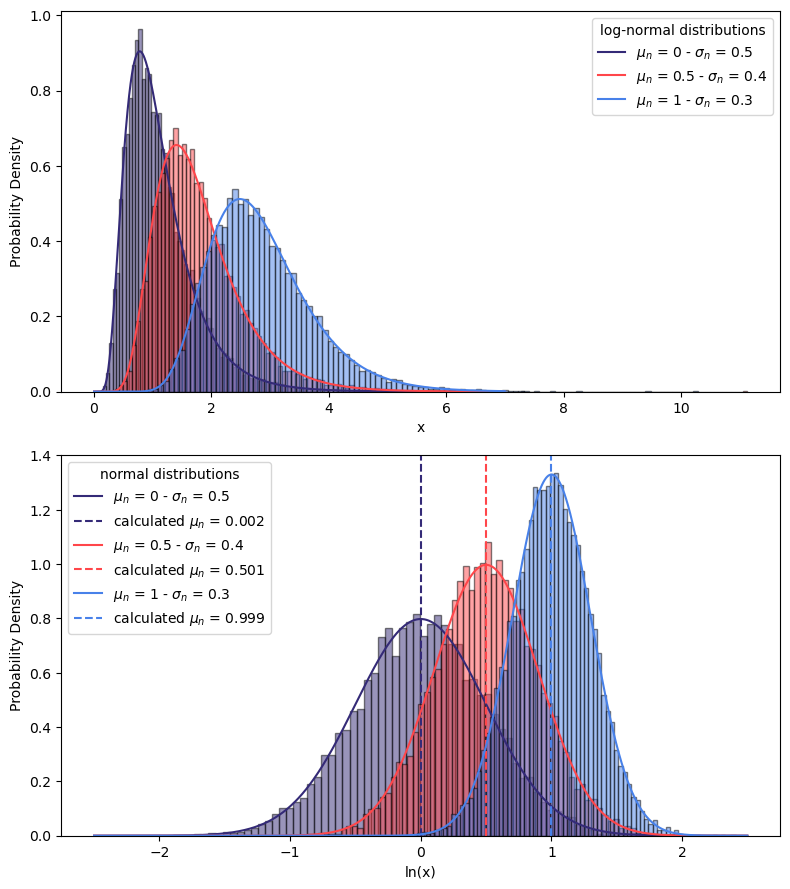

In [ ]:
# Mengimpor library untuk plotting
import matplotlib.pyplot as plt
# Mengimpor NumPy untuk komputasi numerik
import numpy as np 
# Mengimpor distribusi normal dan log-normal dari SciPy
from scipy.stats import norm, lognorm

# Warna untuk tiap kurva (biar tiap distribusi beda visual)
colors = ['#342a77', '#ff464a', '#4881e9']
# Parameter mean untuk distribusi log-normal (dalam ruang normal)
normal_mu = [0,0.5,1]
# Parameter standar deviasi untuk distribusi log-normal
normal_sigma = [0.5,0.4,0.3]
# Range nilai x untuk log-normal (harus > 0 karena log-normal hanya untuk x positif)
x = np.arange(0.001, 7, .001) # for the log-normal PDF
# Range nilai x untuk distribusi normal (bisa negatif atau positif)
x1 = np.arange(-2.5, 2.5, .001)  # for the normal PDF

# Membuat figure dengan 2 subplot (atas & bawah)
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize = (8,9))

# Loop untuk setiap kombinasi parameter
for mu_n, sigma_n, color in zip(normal_mu, normal_sigma, colors): 
     # Menghitung PDF log-normal
     # s = sigma (std dev di ruang log)
     # scale = exp(mu) (transformasi dari normal ke log-normal)
     lognorm_pdf = lognorm.pdf(x, s=sigma_n, scale=np.exp(mu_n))
     # Membuat sampel acak dari distribusi log-normal
     r = lognorm.rvs(s=sigma_n, scale=np.exp(mu_n), size=15000)
     # Plot PDF log-normal
     ax1.plot(x, lognorm_pdf, color=color, label=r"$\mu_n$ = " + str(mu_n) + r" - $\sigma_n$ = " + str(sigma_n))
     # Plot histogram dari sampel log-normal
     ax1.hist(r, bins='auto', density=True, color=color, edgecolor='#000000', alpha=0.5)
     # Mengubah data log-normal ke normal dengan log natural
     logr= np.log(r)
     # PDF normal teoritis dari parameter (mu, sigma)
     normal_pdf = norm.pdf(x1, loc= mu_n, scale = sigma_n)
     # Plot PDF normal
     ax2.plot(x1, normal_pdf, color=color, label=r"$\mu_n$ = " + str(mu_n) + r" - $\sigma_n$ = " + str(sigma_n))
     # Histogram dari data hasil transformasi log
     ax2.hist(logr, bins='auto', density=True, color=color, edgecolor='#000000', alpha=0.5)
     # Mean hasil transformasi log (harus mendekati mu)
     my_mu = logr.mean()
     # Menambahkan garis vertikal untuk mean hasil data
     ax2.axvline(x=my_mu, color=color, linestyle="--", label=r"calculated $\mu_n$ = " + str(round(my_mu,3)))
     # Standar deviasi hasil transformasi log
     my_sigma = logr.std()

     # Menampilkan hasil perbandingan mean
     print("Expected mean: " + str(mu_n) + " - Calculated mean: " + str(round(my_mu,3)))
     # Menampilkan hasil perbandingan standar deviasi
     print("Expected std.dev.: " + str(sigma_n) + " - Calculated std.dev.: " + str(round(my_sigma,3)))
     
# Legend untuk log-normal
ax1.legend(title="log-normal distributions")   
# Label sumbu X untuk plot atas
ax1.set_xlabel('x') 
# Label sumbu Y untuk plot atas
ax1.set_ylabel('Probability Density') 
# Legend untuk normal
ax2.legend(title="normal distributions")
# Label sumbu X untuk plot bawah (log domain)
ax2.set_xlabel('ln(x)')
# Label sumbu Y untuk plot bawah
ax2.set_ylabel('Probability Density')  

# Mengatur layout agar tidak overlap
fig.tight_layout()

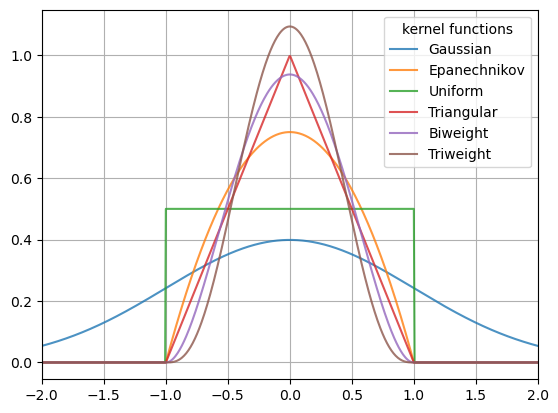

In [ ]:
# Mengimpor KDE (Kernel Density Estimation) univariat dari statsmodels
from statsmodels.nonparametric.kde import KDEUnivariate
# Mengimpor matplotlib untuk plotting
import matplotlib.pyplot as plt
# Mengimpor numpy untuk operasi numerik
import numpy as np

# Daftar jenis kernel yang akan diuji
# gau = Gaussian, epa = Epanechnikov, dst.
kernels = ['gau', 'epa', 'uni', 'tri', 'biw', 'triw']
kernels_names = ['Gaussian', 'Epanechnikov', 'Uniform', 'Triangular', 'Biweight', 'Triweight']
# Posisi (tidak terlalu dipakai di plot ini, hanya dibuat sebagai index)
positions = np.arange(1,9,1)


# Membuat figure dan axis untuk plot
fig, ax = plt.subplots()

# Loop untuk setiap kernel
for kernel, kernel_name, pos in zip(kernels, kernels_names, positions):
    # Membuat objek KDE dengan data sample (di sini hanya satu data: [0])
    kde = KDEUnivariate([0])
    # Melakukan fitting KDE:
    # kernel = jenis kernel smoothing
    # bw = bandwidth (lebar smoothing)
    # fft=False -> tidak pakai FFT untuk estimasi
    # gridsize -> resolusi grid untuk estimasi density
    kde.fit(kernel= kernel, bw=1,  fft=False, gridsize=2**10)
    # kde.support = sumbu x (range nilai)
    # kde.density = hasil estimasi PDF
    ax.plot(kde.support, kde.density, label = kernel_name, linewidth=1.5, alpha=0.8)

# Mengatur batas sumbu X
ax.set_xlim(-2,2)
# Menampilkan grid agar lebih mudah dibaca
ax.grid()
# Menampilkan legend dengan judul
ax.legend(title='kernel functions')

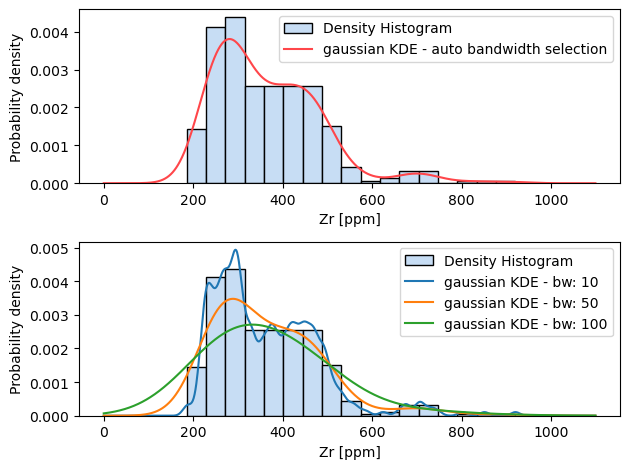

In [ ]:
# Mengimpor KDE (Kernel Density Estimation) univariat
from statsmodels.nonparametric.kde import KDEUnivariate
# Mengimpor pandas untuk membaca data Excel
import pandas as pd
# Mengimpor numpy untuk operasi numerik
import numpy as np
# Mengimpor matplotlib untuk visualisasi
import matplotlib.pyplot as plt

# Membaca file Excel dan memilih sheet "Supp_traces"
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# Mengambil kolom Zr sebagai data analisis
x = my_dataset.Zr
# Membuat grid nilai x untuk evaluasi KDE (0 sampai 1100 ppm)
x_eval = np.arange(0, 1100, 1)

# Membuat figure kosong
fig = plt.figure()

# Membuat subplot pertama (2 baris, 1 kolom, posisi 1)
ax1 = fig.add_subplot(2, 1, 1)
# Histogram densitas dari data Zr
ax1.hist(x, bins='auto', density=True, label='Density Histogram', color='#c7ddf4', edgecolor='#000000') 
# Membuat objek KDE dari data x
kde = KDEUnivariate(x)
# Melakukan fitting KDE dengan bandwidth otomatis
kde.fit()
# Menghitung estimasi density di grid x_eval
my_kde = kde.evaluate(x_eval)
# Plot hasil KDE
ax1.plot(x_eval, my_kde, linewidth=1.5, color='#ff464a', label='gaussian KDE - auto bandwidth selection')
# Label sumbu
ax1.set_xlabel('Zr [ppm]')
ax1.set_ylabel('Probability density')
# Legend
ax1.legend()

# Membuat subplot kedua
ax2 = fig.add_subplot(2, 1, 2)
# Histogram untuk perbandingan
ax2.hist(x, bins= "auto", density = True, label='Density Histogram', color='#c7ddf4', edgecolor='#000000') 

# Menguji pengaruh bandwidth terhadap KDE
for my_bw in [10,50,100]:
    # Membuat KDE baru untuk setiap bandwidth
    kde = KDEUnivariate(x)
    # Fitting KDE dengan bandwidth manual
    kde.fit(bw = my_bw)
    # Menghitung density KDE pada grid
    my_kde = kde.evaluate(x_eval)
    # Plot hasil KDE
    ax2.plot(x_eval, my_kde, linewidth = 1.5, label='gaussian KDE - bw: ' + str(my_bw))
    
# Label subplot 2
ax2.set_xlabel('Zr [ppm]')
ax2.set_ylabel('Probability density')
# Legend subplot 2
ax2.legend()

# Mengatur layout agar tidak tumpang tindih
fig.tight_layout()

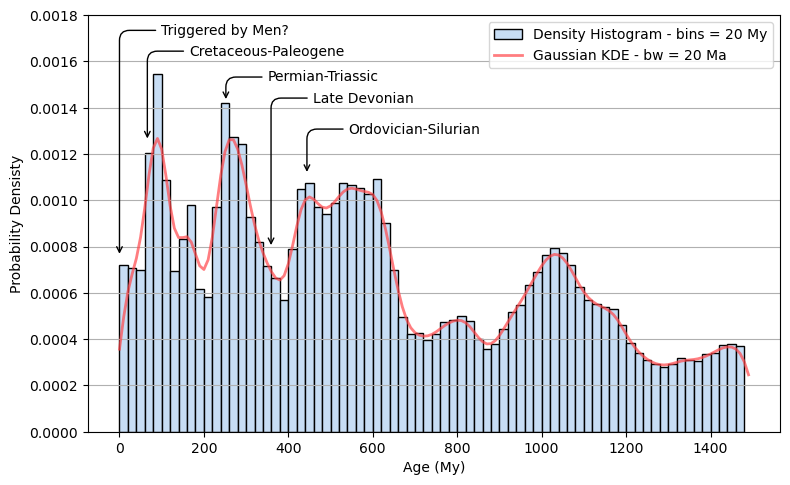

In [ ]:
# untuk membaca dan mengolah data tabel (Excel)
import pandas as pd
# untuk membuat grafik
import matplotlib.pyplot as plt
# untuk operasi numerik
import numpy as np
# KDE (Kernel Density Estimation)
from statsmodels.nonparametric.kde import KDEUnivariate

# Membaca file Excel (data umur zircon)
# import Zircon data from Puetz (2010)        
my_data = pd.read_excel('1-s2.0-S1674987117302141-mmc1.xlsx', sheet_name='Data')
# Filtering data:
# hanya umur > 0 dan < 1500 juta tahun (Ma = million years)
my_data = my_data[(my_data.age206Pb_238U>0)&(my_data.age206Pb_238U<1500)]
# Mengambil kolom umur sebagai sampel utama
my_sample = my_data.age206Pb_238U

# Membuat figure dan axis
fig, ax = plt.subplots(figsize=(8,5))
# Menentukan bin histogram setiap 20 juta tahun
bins = np.arange(0,1500,20)
# Histogram density (estimasi distribusi kasar)
ax.hist(my_sample, bins, color='#c7ddf4', edgecolor='k', density=True, label='Density Histogram - bins = 20 My')

# Grid nilai x untuk evaluasi KDE (resolusi 10 My)
age_eval = np.arange(0,1500,10)
# Membuat KDE dari data umur zircon
kde = KDEUnivariate(my_sample)
# Melakukan fitting KDE dengan bandwidth = 20 Ma
# bandwidth 20 artinya smoothing dalam skala 20 juta tahun
kde.fit(bw=20)
# Menghitung PDF (density) pada grid
pdf = kde.evaluate(age_eval)
# Plot kurva KDE (halus dibanding histogram)
ax.plot(age_eval, pdf, label ='Gaussian KDE - bw = 20 Ma', linewidth=2, alpha=0.7, color='#ff464a')

# batas sumbu Y (density kecil karena data besar)
ax.set_ylim(0,0.0018)
# label sumbu X (umur dalam juta tahun)
ax.set_xlabel('Age (My)')
# label sumbu Y
ax.set_ylabel('Probability Densisty')
# legenda
ax.legend()
# grid horizontal saja
ax.grid(axis='y')

# Daftar waktu kejadian kepunahan massal (dalam juta tahun)
mass_extinction_age = [444, 359, 252, 66, 0]
# Menghitung nilai KDE pada titik-titik tersebut
pdf_mass_extinction_age = kde.evaluate(mass_extinction_age)
# Nama-nama kejadian geologi
mass_extincyion_name = ["Ordovician-Silurian", "Late Devonian", "Permian-Triassic", "Cretaceous-Paleogene", "Triggered by Men?"]
# Posisi offset teks (agar label tidak menumpuk)
y_offsets = [0.0001, 0.0001, 0.0002, 0.0002, 0.0004]
y_texts = [30, 105, 15, 62, 160]
x_texts = [30, 30, 30, 30, 30]

# Loop untuk memberi anotasi pada tiap event
for x, y, name, x_text, y_text, y_offset in zip(mass_extinction_age, pdf_mass_extinction_age, mass_extincyion_name, x_texts, y_texts, y_offsets):
    # titik panah (data KDE)
    ax.annotate(name, xy=(x, y + y_offset), xycoords='data',
    # posisi teks (offset dari titik)
    xytext=(x_text, y_text), textcoords='offset points',
    # gaya panah
    arrowprops=dict(arrowstyle="->",
    connectionstyle="angle, angleA=0, angleB=90, rad=10"))

# menghindari overlap elemen plot
fig.tight_layout()

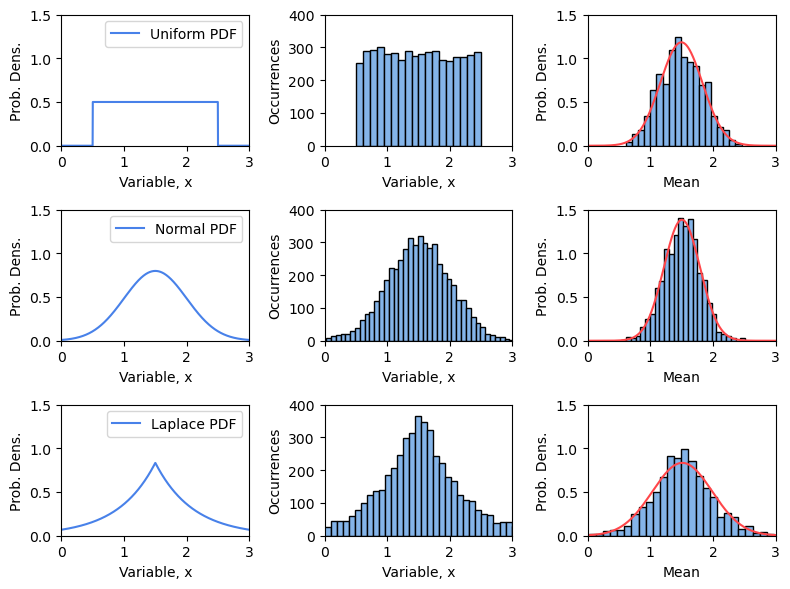

In [ ]:
# operasi numerik
import numpy as np
# distribusi probabilitas (uniform, normal, laplace)
import scipy.stats as stats
# plotting grafik
import matplotlib.pyplot as plt

# Membuat figure utama dengan ukuran 8x6
fig = plt.figure(figsize=(8,6))

# Tiga distribusi berbeda:
# 1. Uniform → semua nilai punya peluang sama
# 2. Normal → distribusi lonceng (Gaussian)
# 3. Laplace → mirip normal tapi lebih tajam di tengah (heavy peak)
dists = [stats.uniform(loc=0.5, scale=2), stats.norm(loc=1.5, scale=0.5), stats.laplace(loc=1.5, scale=0.6)]
names = ['Uniform', 'Normal', 'Laplace']
# Grid nilai x untuk plotting PDF
x = np.linspace(0,3,1000)

# loop untuk distribusi
for i, (dist, name) in enumerate(zip(dists, names)):
    
    # Menghitung fungsi densitas probabilitas (PDF)
    pdf = dist.pdf(x)
    # Subplot posisi: baris 1 kolom 3 (PDF)
    ax1 = fig.add_subplot(3, 3, 3*i+1)
    # Plot PDF
    ax1.plot(x, pdf, color='#4881e9', label= name + ' PDF')
    # Batas tampilan grafik
    ax1.set_xlim(0,3)
    ax1.set_ylim(0,1.5)
    ax1.set_xlabel('Variable, x')
    ax1.set_ylabel('Prob. Dens.')
    ax1.legend()
    
    # Mengambil 5000 sampel acak dari distribusi
    rnd = dist.rvs(size=5000)
    # Subplot histogram data acak
    ax2 = fig.add_subplot(3, 3, 3*i+2)
    # Histogram distribusi data
    ax2.hist(rnd, bins='auto', color='#84b4e8', edgecolor='#000000')
    ax2.set_xlim(0,3)
    ax2.set_ylim(0,400)
    ax2.set_xlabel('Variable, x')
    ax2.set_ylabel('Occurrences')
    
    # Menyimpan hasil mean dari sampling berulang
    ax3 = fig.add_subplot(3, 3, 3*i+3)
    mean_dist = []
    # Mengulang 1000 kali:
    # setiap kali ambil 3 sampel → hitung mean
    for _ in range(1000):
        mean_dist.append(dist.rvs(size=3).mean())
    # Konversi ke array NumPy
    mean_dist = np.array(mean_dist)
    # Histogram distribusi mean
    ax3.hist(mean_dist, density=True, bins='auto',  color='#84b4e8', edgecolor='#000000')
    # Membuat distribusi normal fit dari hasil mean
    normal = stats.norm(loc= mean_dist.mean(), scale= mean_dist.std())
    # Plot kurva normal (aproksimasi CLT)
    ax3.plot(x, normal.pdf(x), color='#ff464a')
    ax3.set_xlim(0,3)
    ax3.set_ylim(0,1.5)
    ax3.set_xlabel('Mean')
    ax3.set_ylabel('Prob. Dens.')
    
fig.tight_layout() # tampilan